# 🏦 Loan Approval Prediction — End-to-End ML Project
**Devixo Solutions · AI/ML Internship · Task 04**

Pipeline of this notebook:
1. Load & explore data → 2. Clean (missing values, duplicates, outliers) → 3. Feature engineering
4. Train & compare 5 models → 5. Hyperparameter tuning (GridSearchCV) → 6. Before vs after tuning
7. Select best model → 8. Feature importance → 9. Save model for the Streamlit app

In [23]:
import warnings
warnings.filterwarnings("ignore")
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


import joblib

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report)
from sklearn.inspection import permutation_importance

# our own helper module (custom transformer + data helpers)
from loan_utils import (FeatureEngineer, NUMERIC_FEATURES, CATEGORICAL_FEATURES, RAW_FEATURES,
                        OUTLIER_COLS, load_clean_data, get_xy, split_data)



## 1. Load the data

In [24]:
raw = pd.read_csv("LoanApprovalPrediction.csv")
print("Shape:", raw.shape)
raw.head()

Shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [25]:
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


## 2. Data cleaning
### 2.1 Missing values

Credit_History      50
Self_Employed       32
LoanAmount          22
Dependents          15
Loan_Amount_Term    14
Gender              13
Married              3
dtype: int64


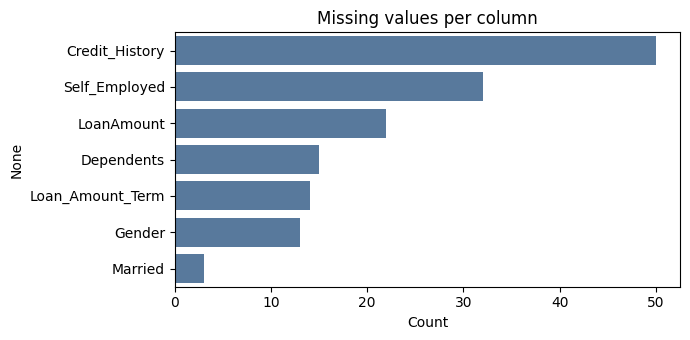

In [26]:
missing = raw.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

plt.figure(figsize=(7, 3.5))
sns.barplot(x=missing.values, y=missing.index, color="#4C78A8")
plt.title("Missing values per column")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

Missing values are **not** filled here on the full dataset (that would leak information from the test set).
They are filled **inside the pipeline**: median for numeric columns, most frequent value for categorical columns.

### 2.2 Duplicates and useless columns

In [27]:
print("Duplicate rows:", raw.duplicated().sum())
print("Unique Loan_IDs:", raw["Loan_ID"].nunique(), "out of", len(raw))

# Loan_ID is just a unique label (LP001002 ...). It carries no information, so it is dropped.
df = load_clean_data("LoanApprovalPrediction.csv")
print("Shape after cleaning:", df.shape)

Duplicate rows: 0
Unique Loan_IDs: 614 out of 614
Shape after cleaning: (614, 12)


## 3. Exploratory data analysis

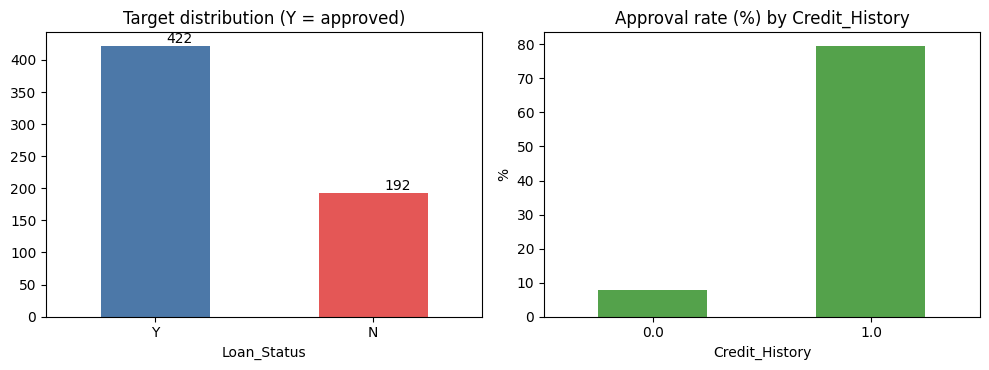

In [28]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))
df["Loan_Status"].value_counts().plot.bar(ax=ax[0], color=["#4C78A8", "#E45756"], rot=0)
ax[0].set_title("Target distribution (Y = approved)")
for p in ax[0].patches:
    ax[0].annotate(int(p.get_height()), (p.get_x() + 0.3, p.get_height() + 5))
(df.groupby("Credit_History")["Loan_Status"].apply(lambda s: (s == "Y").mean() * 100)
   .plot.bar(ax=ax[1], color="#54A24B", rot=0))
ax[1].set_title("Approval rate (%) by Credit_History")
ax[1].set_ylabel("%")
plt.tight_layout()
plt.show()

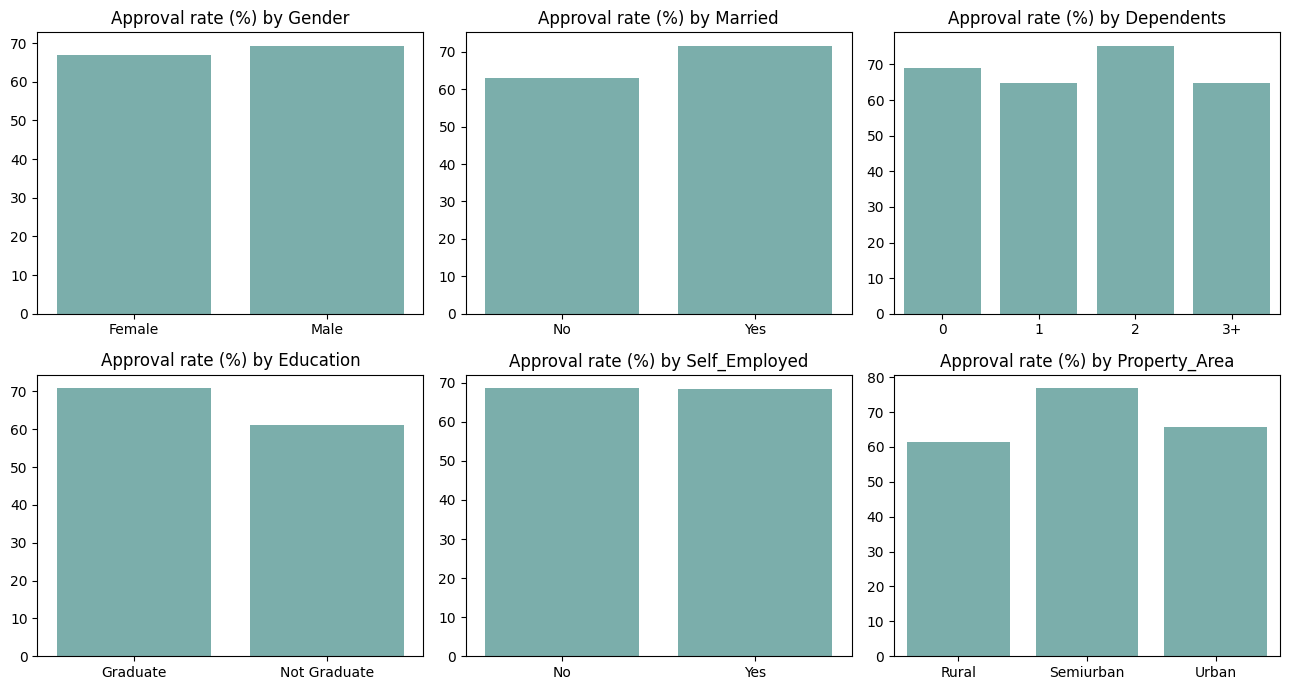

In [29]:
cats = ["Gender", "Married", "Dependents", "Education", "Self_Employed", "Property_Area"]
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, c in zip(axes.ravel(), cats):
    rate = df.groupby(c)["Loan_Status"].apply(lambda s: (s == "Y").mean() * 100)
    sns.barplot(x=rate.index.astype(str), y=rate.values, ax=ax, color="#72B7B2")
    ax.set_title(f"Approval rate (%) by {c}")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

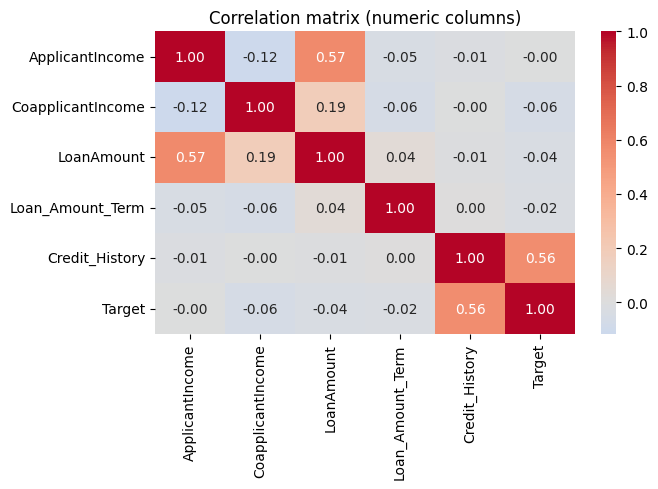

In [30]:
tmp = df.copy()
tmp["Target"] = (tmp["Loan_Status"] == "Y").astype(int)
plt.figure(figsize=(7, 5))
sns.heatmap(tmp.select_dtypes("number").corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation matrix (numeric columns)")
plt.tight_layout()
plt.show()

### 2.3 Outlier detection (IQR rule)

           Column  Lower bound  Upper bound  Outliers  % of rows
  ApplicantIncome      -1498.8      10171.2        50        8.1
CoapplicantIncome      -3445.9       5743.1        18        2.9
       LoanAmount         -2.0        270.0        39        6.6


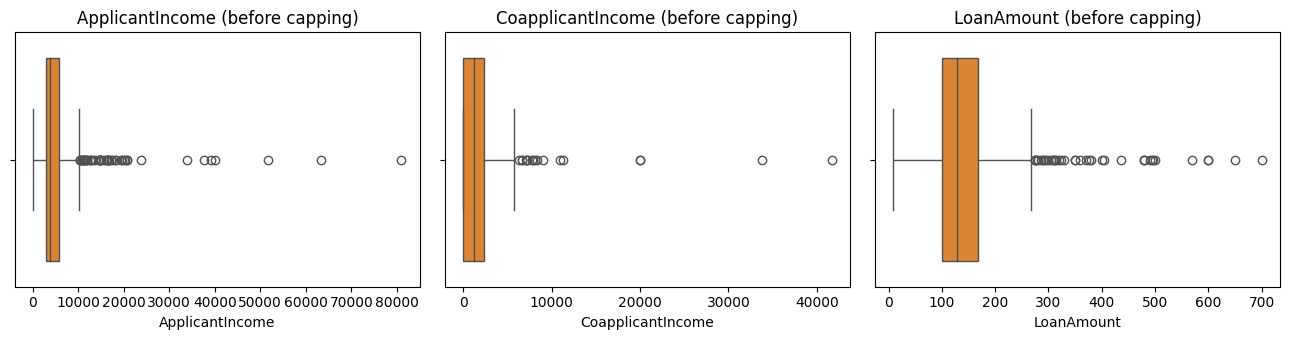

In [31]:
rows = []
for col in OUTLIER_COLS:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < low) | (df[col] > high)).sum()
    rows.append([col, round(low, 1), round(high, 1), n_out, round(n_out / df[col].notna().sum() * 100, 1)])
print(pd.DataFrame(rows, columns=["Column", "Lower bound", "Upper bound", "Outliers", "% of rows"]).to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, col in zip(axes, OUTLIER_COLS):
    sns.boxplot(x=df[col], ax=ax, color="#F58518")
    ax.set_title(f"{col} (before capping)")
plt.tight_layout()
plt.show()

Incomes and loan amounts are heavily right-skewed. Rows are **not deleted** (the dataset is small);
instead the values are **capped at the IQR bounds** by the `FeatureEngineer` step of the pipeline.
The bounds are learned from the training data only.

## 4. Feature engineering
The `FeatureEngineer` transformer (in `loan_utils.py`) caps outliers and adds:

| New feature | Meaning |
|---|---|
| `TotalIncome` | Applicant + Coapplicant income |
| `EMI` | Monthly instalment = LoanAmount / Loan_Amount_Term |
| `Loan_to_Income` | Loan amount relative to total income |
| `Balance_Income` | Income left after paying the EMI |
| `Log_TotalIncome` | Log of total income (reduces skew) |

In [32]:
X, y = get_xy(df)
X_train, X_test, y_train, y_test = split_data(X, y)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Approval rate  train: %.3f   test: %.3f" % (y_train.mean(), y_test.mean()))

# Quick look at what the engineered data looks like
fe_preview = FeatureEngineer().fit(X_train).transform(X_train)
fe_preview[["ApplicantIncome", "TotalIncome", "EMI", "Loan_to_Income", "Balance_Income", "Log_TotalIncome"]].describe().round(2)

Train: (491, 11)  Test: (123, 11)
Approval rate  train: 0.686   test: 0.691


,ApplicantIncome,TotalIncome,EMI,Loan_to_Income,Balance_Income,Log_TotalIncome
count,491.00,491.00,459.00,471.00,459.00,491.00
mean,4666.25,6052.79,0.47,23.99,5603.79,8.62
std,2468.39,2607.82,0.53,7.29,2545.65,0.42
min,210.00,1442.00,0.02,3.78,-1768.00,7.27
25%,2906.00,4177.00,0.29,19.85,3788.67,8.34
50%,3859.00,5391.00,0.37,24.40,4938.22,8.59
75%,5825.00,7541.50,0.52,27.79,6988.17,8.93
max,10203.50,15806.00,9.25,82.71,15056.00,9.67


## 5. Preprocessing pipeline
Everything (outlier capping → feature engineering → imputing → scaling → encoding → model) is in **one pipeline**.
This means the Streamlit app can pass raw user input straight to the saved model.

In [33]:
preprocessor = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), NUMERIC_FEATURES),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("encoder", OneHotEncoder(handle_unknown="ignore"))]), CATEGORICAL_FEATURES),
])


def make_pipeline(model):
    return Pipeline([("fe", FeatureEngineer()), ("prep", preprocessor), ("model", model)])


# class_weight="balanced" handles the imbalance (about 69% approved / 31% rejected)
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight="balanced"),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42, class_weight="balanced"),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## 6. Train and compare 5 models (before tuning)
Metrics are for the **Approved (Y)** class on the test set, plus 5-fold cross-validated ROC-AUC on the training set.

In [34]:
def evaluate(pipe, name, stage):
    pred = pipe.predict(X_test)
    prob = pipe.predict_proba(X_test)[:, 1]
    return {
        "Model": name, "Stage": stage,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "ROC_AUC": roc_auc_score(y_test, prob),
        "Reject_Recall": recall_score(y_test, pred, pos_label=0),
    }


baseline_rows, baseline_pipes = [], {}
for name, model in models.items():
    pipe = make_pipeline(model).fit(X_train, y_train)
    row = evaluate(pipe, name, "Before tuning")
    row["CV_ROC_AUC"] = cross_val_score(make_pipeline(model), X_train, y_train, cv=cv, scoring="roc_auc").mean()
    baseline_rows.append(row)
    baseline_pipes[name] = pipe

baseline = pd.DataFrame(baseline_rows)
cols = ["Model", "Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "Reject_Recall", "CV_ROC_AUC"]
baseline[cols].round(4).sort_values("CV_ROC_AUC", ascending=False).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,Reject_Recall,CV_ROC_AUC
0,Random Forest,0.8862,0.8989,0.9412,0.9195,0.8463,0.7632,0.7651
1,SVM,0.8455,0.8750,0.9059,0.8902,0.8567,0.7105,0.7557
2,Logistic Regression,0.8699,0.9157,0.8941,0.9048,0.8746,0.8158,0.7304
3,Gradient Boosting,0.8455,0.8511,0.9412,0.8939,0.8598,0.6316,0.7281
4,Decision Tree,0.8049,0.9178,0.7882,0.8481,0.8152,0.8421,0.6457


## 7. Hyperparameter tuning with GridSearchCV
Each model is tuned with 5-fold stratified CV, optimising **ROC-AUC**
(it does not depend on a threshold and works well for imbalanced data).

In [35]:
param_grids = {
    "Logistic Regression": {"model__C": [0.01, 0.1, 1, 10, 100]},
    "Decision Tree": {"model__max_depth": [3, 4, 5, 7, None],
                      "model__min_samples_leaf": [1, 5, 10, 20]},
    "Random Forest": {"model__n_estimators": [100, 300],
                      "model__max_depth": [3, 5, 8, None],
                      "model__min_samples_leaf": [1, 3, 5, 10]},
    "Gradient Boosting": {"model__n_estimators": [50, 100, 200],
                          "model__learning_rate": [0.03, 0.1],
                          "model__max_depth": [2, 3]},
    "SVM": {"model__C": [0.5, 1, 5, 10],
            "model__kernel": ["rbf", "linear"]},
}

tuned_pipes, best_params, tuned_rows = {}, {}, []
for name, model in models.items():
    gs = GridSearchCV(make_pipeline(model), param_grids[name], cv=cv, scoring="roc_auc", n_jobs=-1)
    gs.fit(X_train, y_train)
    tuned_pipes[name] = gs.best_estimator_
    best_params[name] = {k.replace("model__", ""): v for k, v in gs.best_params_.items()}
    row = evaluate(gs.best_estimator_, name, "After tuning")
    row["CV_ROC_AUC"] = gs.best_score_
    tuned_rows.append(row)
    print(f"{name:20s} best params: {best_params[name]}   CV ROC-AUC = {gs.best_score_:.4f}")

tuned = pd.DataFrame(tuned_rows)

Logistic Regression  best params: {'C': 1}   CV ROC-AUC = 0.7304
Decision Tree        best params: {'max_depth': 7, 'min_samples_leaf': 20}   CV ROC-AUC = 0.7375
Random Forest        best params: {'max_depth': 8, 'min_samples_leaf': 1, 'n_estimators': 300}   CV ROC-AUC = 0.7702
Gradient Boosting    best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}   CV ROC-AUC = 0.7435
SVM                  best params: {'C': 0.5, 'kernel': 'rbf'}   CV ROC-AUC = 0.7571


## 8. Before vs After tuning

In [36]:
compare = baseline[["Model", "Accuracy", "F1", "ROC_AUC", "CV_ROC_AUC"]].merge(
    tuned[["Model", "Accuracy", "F1", "ROC_AUC", "CV_ROC_AUC"]], on="Model", suffixes=(" (before)", " (after)"))
compare = compare[["Model", "Accuracy (before)", "Accuracy (after)", "F1 (before)", "F1 (after)",
                   "ROC_AUC (before)", "ROC_AUC (after)", "CV_ROC_AUC (before)", "CV_ROC_AUC (after)"]]
compare.round(4)

,Model,Accuracy (before),Accuracy (after),F1 (before),F1 (after),ROC_AUC (before),ROC_AUC (after),CV_ROC_AUC (before),CV_ROC_AUC (after)
0,Logistic Regression,0.8699,0.8699,0.9048,0.9048,0.8746,0.8746,0.7304,0.7304
1,Decision Tree,0.8049,0.7724,0.8481,0.8205,0.8152,0.8370,0.6457,0.7375
2,Random Forest,0.8862,0.8699,0.9195,0.9091,0.8463,0.8709,0.7651,0.7702
3,Gradient Boosting,0.8455,0.8537,0.8939,0.8989,0.8598,0.8842,0.7281,0.7435
4,SVM,0.8455,0.8374,0.8902,0.8837,0.8567,0.8502,0.7557,0.7571


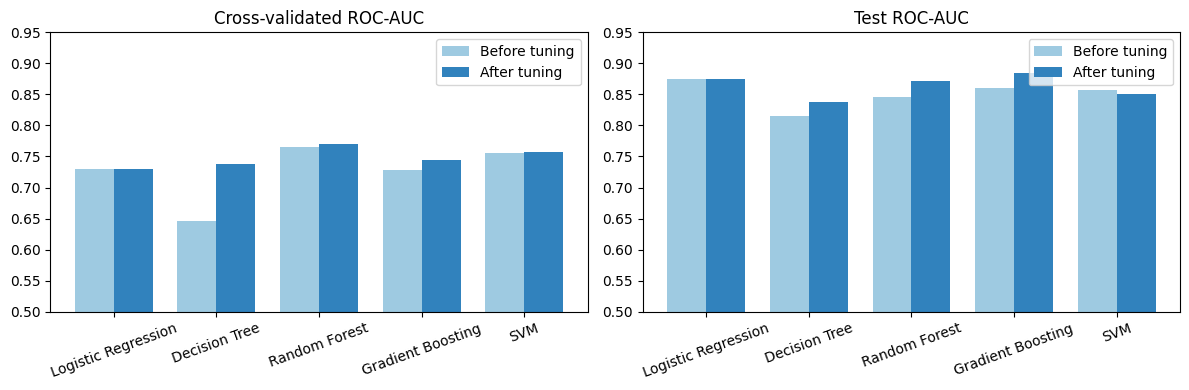

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(len(models)); w = 0.38
for ax, metric in zip(axes, ["CV_ROC_AUC", "ROC_AUC"]):
    ax.bar(x - w / 2, baseline[metric], w, label="Before tuning", color="#9ecae1")
    ax.bar(x + w / 2, tuned[metric], w, label="After tuning", color="#3182bd")
    ax.set_xticks(x); ax.set_xticklabels(list(models), rotation=20)
    ax.set_title(("Cross-validated " if metric.startswith("CV") else "Test ") + "ROC-AUC")
    ax.set_ylim(0.5, 0.95); ax.legend()
plt.tight_layout()
plt.show()

## 9. Select the best model
The final model is chosen by **cross-validated ROC-AUC on the training data** (not on the test set),
so the test set stays an honest, unseen check.

In [38]:
best_name = tuned.sort_values("CV_ROC_AUC", ascending=False).iloc[0]["Model"]
best_model = tuned_pipes[best_name]
print("✅ Best model:", best_name)
print("Best parameters:", best_params[best_name])

✅ Best model: Random Forest
Best parameters: {'max_depth': 8, 'min_samples_leaf': 1, 'n_estimators': 300}


In [39]:
pred = best_model.predict(X_test)
prob = best_model.predict_proba(X_test)[:, 1]
print(f"Accuracy : {accuracy_score(y_test, pred):.4f}")
print(f"Precision: {precision_score(y_test, pred):.4f}")
print(f"Recall   : {recall_score(y_test, pred):.4f}")
print(f"F1-score : {f1_score(y_test, pred):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, prob):.4f}")
print()
print(classification_report(y_test, pred, target_names=["Rejected (N)", "Approved (Y)"]))

Accuracy : 0.8699
Precision: 0.8791
Recall   : 0.9412
F1-score : 0.9091
ROC-AUC  : 0.8709

              precision    recall  f1-score   support

Rejected (N)       0.84      0.71      0.77        38
Approved (Y)       0.88      0.94      0.91        85

    accuracy                           0.87       123
   macro avg       0.86      0.83      0.84       123
weighted avg       0.87      0.87      0.87       123



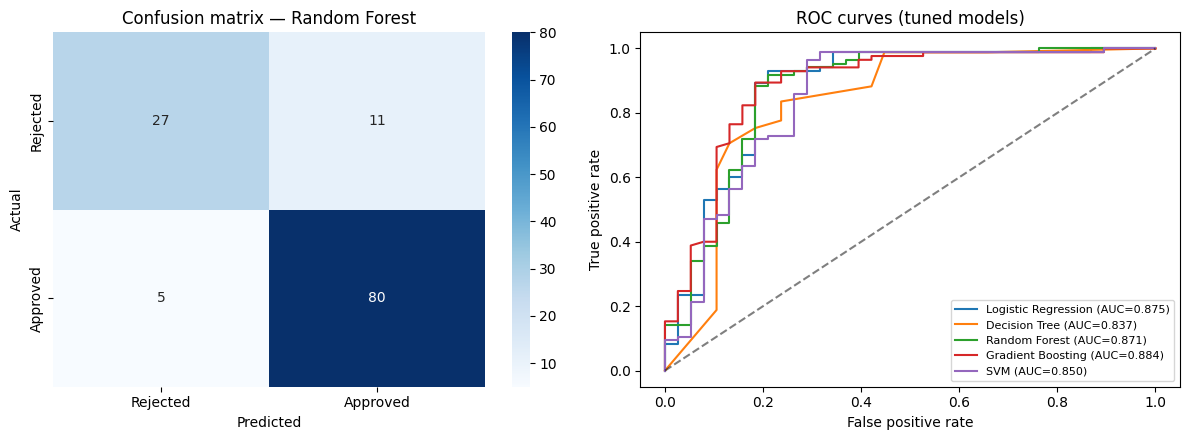

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Rejected", "Approved"], yticklabels=["Rejected", "Approved"])
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
axes[0].set_title(f"Confusion matrix — {best_name}")

for name, pipe in tuned_pipes.items():
    fpr, tpr, _ = roc_curve(y_test, pipe.predict_proba(X_test)[:, 1])
    axes[1].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1]):.3f})")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[1].set_xlabel("False positive rate"); axes[1].set_ylabel("True positive rate")
axes[1].set_title("ROC curves (tuned models)"); axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 10. Feature importance (permutation importance)
Works for every model type: shuffle one input column and measure how much the test ROC-AUC drops.

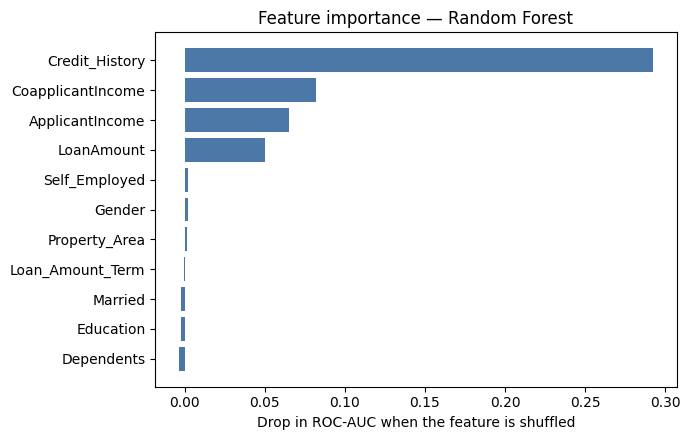

In [41]:
importance = {}
for name, pipe in tuned_pipes.items():
    r = permutation_importance(pipe, X_test, y_test, scoring="roc_auc", n_repeats=20, random_state=42)
    importance[name] = pd.Series(r.importances_mean, index=X_test.columns)

imp_df = pd.DataFrame(importance)
imp_best = imp_df[best_name].sort_values()

plt.figure(figsize=(7, 4.5))
plt.barh(imp_best.index, imp_best.values, color="#4C78A8")
plt.title(f"Feature importance — {best_name}")
plt.xlabel("Drop in ROC-AUC when the feature is shuffled")
plt.tight_layout()
plt.show()

## 11. Save everything the Streamlit app needs

In [42]:
joblib.dump(best_model, "loan_approval_model.joblib", compress=3)

joblib.dump(tuned_pipes, "all_models.joblib", compress=3)

pd.concat([baseline, tuned]).to_csv("model_results.csv", index=False)

imp_df.to_csv("feature_importance.csv")

with open("model_meta.json", "w") as f:
    json.dump(
        {"best_model": best_name, "best_params": best_params},
        f,
        indent=2,
        default=str
    )

## 12. Final check — load the saved model and predict from raw input

In [43]:
saved = joblib.load("loan_approval_model.joblib")

good = pd.DataFrame([{"Gender": "Male", "Married": "Yes", "Dependents": "0", "Education": "Graduate",
                      "Self_Employed": "No", "ApplicantIncome": 6000, "CoapplicantIncome": 2000,
                      "LoanAmount": 120, "Loan_Amount_Term": 360, "Credit_History": 1.0,
                      "Property_Area": "Urban"}])
bad = good.copy()
bad["Credit_History"] = 0.0
bad["ApplicantIncome"] = 2000
bad["LoanAmount"] = 300

for label, row in [("Good applicant", good), ("Weak applicant", bad)]:
    p = saved.predict_proba(row)[0, 1]
    print(f"{label}: {'APPROVED' if saved.predict(row)[0] == 1 else 'REJECTED'}  (approval probability {p:.1%})")

Good applicant: APPROVED  (approval probability 65.3%)
Weak applicant: REJECTED  (approval probability 19.4%)
